# Laboratorio 7 - Punto 2: CelebA Faces - Aprendizaje No Supervisado, Semisupervisado y Activo

Este cuaderno aborda el análisis de un subconjunto del dataset **CelebA** aplicando técnicas avanzadas de Machine Learning:

1. **Generador de Dataset Aleatorio Mejorado:** Generación de centroides entre 1 y 20 con distancia importante entre ellos, más demostración de KMeans, Método del Codo y Silhouette Score.
2. **Aprendizaje No Supervisado:** Agrupamiento de rostros usando K-Means tras reducción de dimensionalidad con PCA.
3. **Aprendizaje Semisupervisado:** Propagación de etiquetas a partir de representantes de cada cluster.
4. **Aprendizaje Activo:** Selección iterativa de los ejemplos más inciertos para mejorar un modelo con mínimas etiquetas.

---
**Dataset:** CelebA (Large-scale CelebFaces Attributes Dataset)  
- **m > 10,000 imágenes** (se cargan 20,000)  
- **n > 10 features** (4096 píxeles aplanados → reducidos con PCA)  
- Las imágenes **no tienen etiquetas de clase** asignadas previamente (solo atributos binarios en CSV)

---
## PARTE 1: Generador de Dataset Aleatorio y Demostración de KMeans

### 1.1 Importaciones Generales

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FixedLocator, FixedFormatter
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import random
import warnings
warnings.filterwarnings("ignore")

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


### 1.2 Generador de Dataset Aleatorio Mejorado

**Modificación aplicada:** El generador ahora produce entre **1 y 20 centroides** de manera aleatoria. Para garantizar una **importante distancia visual entre los clusters** (lo que permite verificar visualmente la efectividad de KMeans), cada nuevo centroide candidato se acepta solo si está a una distancia mínima de **5 unidades** de todos los centroides ya colocados. Se usa un rango amplio de posiciones `[-50, 50]` para maximizar la separación.

In [2]:
# =========================================================
# GENERADOR DE DATASET ALEATORIO MEJORADO
# - Centroides: entre 1 y 20 (aleatorio)
# - Distancia mínima entre centroides: 5 unidades
# - Rango de posición: [-50, 50] para máxima separación visual
# - Std por cluster: 1.5 (clusters compactos y bien separados)
# =========================================================

random.seed()  # Semilla dinámica para resultados diferentes cada ejecución
np.random.seed()

n_centers = random.randint(1, 20)
print(f"Número de centroides generados aleatoriamente: {n_centers}")

MIN_DISTANCE = 5.0   # Distancia mínima entre centroides
COORD_RANGE  = 50    # Rango de coordenadas [-50, 50]
MAX_ATTEMPTS = 10000 # Máximos intentos antes de reducir la distancia mínima

blob_centers = []
attempts = 0
min_dist = MIN_DISTANCE

while len(blob_centers) < n_centers:
    candidate = np.random.uniform(-COORD_RANGE, COORD_RANGE, size=2)
    if all(np.linalg.norm(candidate - center) > min_dist for center in blob_centers):
        blob_centers.append(candidate)
    attempts += 1
    # Si después de muchos intentos no se puede colocar, reducir distancia mínima
    if attempts > MAX_ATTEMPTS:
        min_dist *= 0.9
        attempts = 0

blob_centers = np.array(blob_centers)
blob_std = np.full(n_centers, 1.5)  # Clusters compactos para separación visual clara

# Generar datos con make_blobs
X, y_true = make_blobs(
    n_samples=2000,
    centers=blob_centers,
    cluster_std=blob_std,
    random_state=None  # Dinámico
)

print(f"\nDataset generado: {X.shape[0]} muestras, {n_centers} clusters")
print("\nCoordenadas de los centroides generados:")
for i, c in enumerate(blob_centers):
    print(f"  Centroide {i:2d}: ({c[0]:7.2f}, {c[1]:7.2f})")

Número de centroides generados aleatoriamente: 14

Dataset generado: 2000 muestras, 14 clusters

Coordenadas de los centroides generados:
  Centroide  0: (  21.77,  -24.21)
  Centroide  1: (  17.83,   14.73)
  Centroide  2: (  -6.61,   -0.45)
  Centroide  3: (  35.05,   -4.68)
  Centroide  4: (  -9.52,   -5.60)
  Centroide  5: ( -39.39,   -1.94)
  Centroide  6: (  15.60,   42.18)
  Centroide  7: (  46.01,  -13.00)
  Centroide  8: (  -3.53,  -35.02)
  Centroide  9: (  35.15,   17.08)
  Centroide 10: (  -6.28,   11.01)
  Centroide 11: ( -35.20,  -38.43)
  Centroide 12: ( -31.03,  -17.00)
  Centroide 13: (   3.90,   39.09)


### 1.3 Visualización del Dataset Generado (Sin Etiquetas)

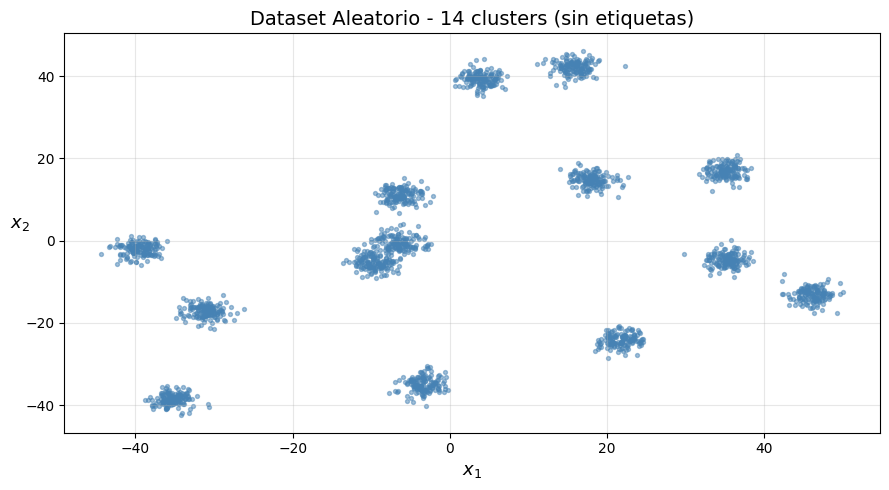

In [3]:
def plot_clusters(X, y=None, title="Dataset"):
    plt.figure(figsize=(9, 5))
    if y is not None:
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap='tab20', s=8, alpha=0.7)
    else:
        plt.scatter(X[:, 0], X[:, 1], color='steelblue', s=8, alpha=0.5)
    plt.xlabel("$x_1$", fontsize=13)
    plt.ylabel("$x_2$", fontsize=13, rotation=0)
    plt.title(title, fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_clusters(X, title=f"Dataset Aleatorio - {n_centers} clusters (sin etiquetas)")

### 1.4 Entrenamiento del Modelo KMeans

KMeans agrupa los datos minimizando la inercia (suma de distancias al cuadrado de cada punto a su centroide). Usamos `k-means++` para una inicialización inteligente que mejora la convergencia.

In [4]:
k = n_centers  # Usamos el k real para demostrar efectividad
kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
y_pred = kmeans.fit_predict(X)

print(f"KMeans entrenado con k={k}")
print(f"Inercia final: {kmeans.inertia_:.2f}")
print(f"Iteraciones realizadas: {kmeans.n_iter_}")

KMeans entrenado con k=14
Inercia final: 9009.76
Iteraciones realizadas: 3


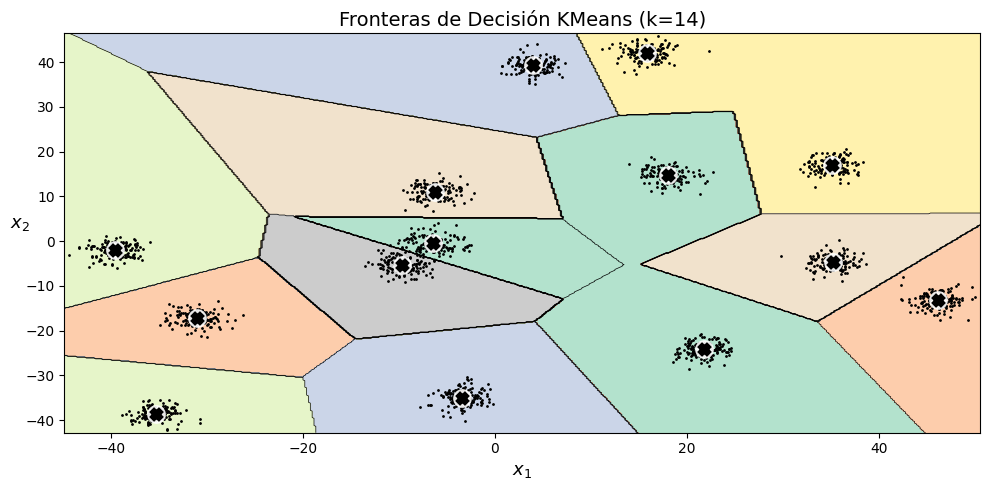

In [5]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, circle_color='white', cross_color='black'):
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=30, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=50, linewidths=5,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=500,
                              show_centroids=True, show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.5
    maxs = X.max(axis=0) + 0.5
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                          np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), cmap='Pastel2')
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=0.5, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)
    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=13)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=13, rotation=0)
    else:
        plt.tick_params(labelleft=False)

plt.figure(figsize=(10, 5))
plot_decision_boundaries(kmeans, X)
plt.title(f"Fronteras de Decisión KMeans (k={k})", fontsize=14)
plt.tight_layout()
plt.show()

### 1.5 Verificación Visual de la Efectividad del Modelo

Comparamos las etiquetas reales (colores del dataset generado) contra las predicciones de KMeans.

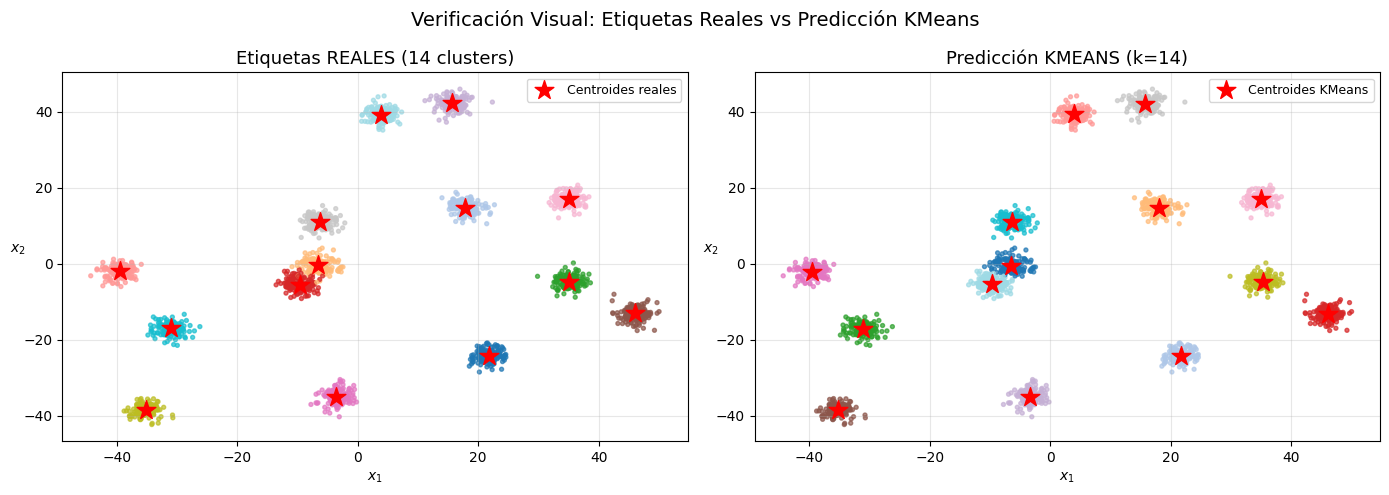


Silhouette Score con k=14 (valor real): 0.7925
(Valores cercanos a 1 indican clusters bien definidos y separados)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Real
axes[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='tab20', s=8, alpha=0.7)
axes[0].scatter(blob_centers[:, 0], blob_centers[:, 1],
                marker='*', s=200, c='red', zorder=5, label='Centroides reales')
axes[0].set_title(f"Etiquetas REALES ({n_centers} clusters)", fontsize=13)
axes[0].set_xlabel("$x_1$"); axes[0].set_ylabel("$x_2$", rotation=0)
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Predicción KMeans
axes[1].scatter(X[:, 0], X[:, 1], c=y_pred, cmap='tab20', s=8, alpha=0.7)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                marker='*', s=200, c='red', zorder=5, label='Centroides KMeans')
axes[1].set_title(f"Predicción KMEANS (k={k})", fontsize=13)
axes[1].set_xlabel("$x_1$"); axes[1].set_ylabel("$x_2$", rotation=0)
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle("Verificación Visual: Etiquetas Reales vs Predicción KMeans", fontsize=14)
plt.tight_layout()
plt.show()

# Silhouette Score del modelo entrenado con k real
if k > 1:
    sil = silhouette_score(X, y_pred)
    print(f"\nSilhouette Score con k={k} (valor real): {sil:.4f}")
    print("(Valores cercanos a 1 indican clusters bien definidos y separados)")

### 1.6 Método del Codo (Elbow Method)

Calculamos la **inercia** (WCSS) para diferentes valores de k. El "codo" de la curva indica el k óptimo donde agregar más clusters deja de aportar mejora significativa.

Calculando inercia para k=1 hasta k=19...


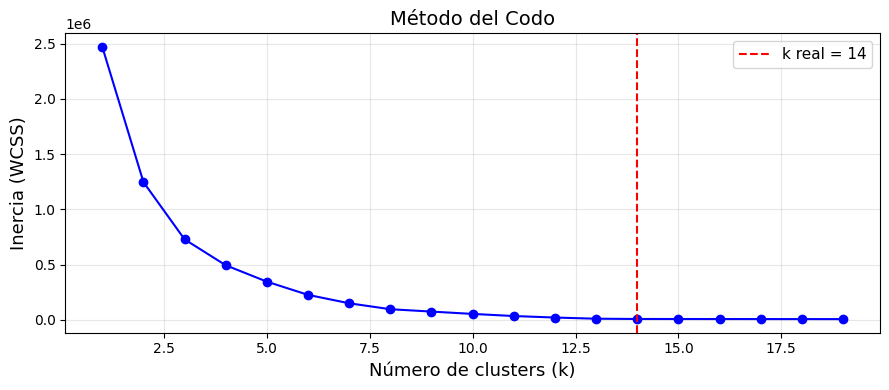


El codo debería observarse cerca de k=14 (línea roja = k real del dataset).


In [7]:
max_k_eval = min(20, max(n_centers + 5, 10))  # Evaluar hasta al menos k+5 o 10

inertias = []
K_range = range(1, max_k_eval + 1)

print(f"Calculando inercia para k=1 hasta k={max_k_eval}...")
for k_val in K_range:
    km = KMeans(n_clusters=k_val, init='k-means++', n_init=10, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(K_range, inertias, 'bo-', markersize=6)
plt.axvline(x=n_centers, color='red', linestyle='--', linewidth=1.5,
            label=f'k real = {n_centers}')
plt.xlabel("Número de clusters (k)", fontsize=13)
plt.ylabel("Inercia (WCSS)", fontsize=13)
plt.title("Método del Codo", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nEl codo debería observarse cerca de k={n_centers} (línea roja = k real del dataset).")

### 1.7 Silhouette Score para Diferentes Valores de k

El **Silhouette Score** mide la calidad del clustering: valores cercanos a 1 indican que las muestras están bien asignadas a su cluster; valores negativos indican asignación incorrecta.

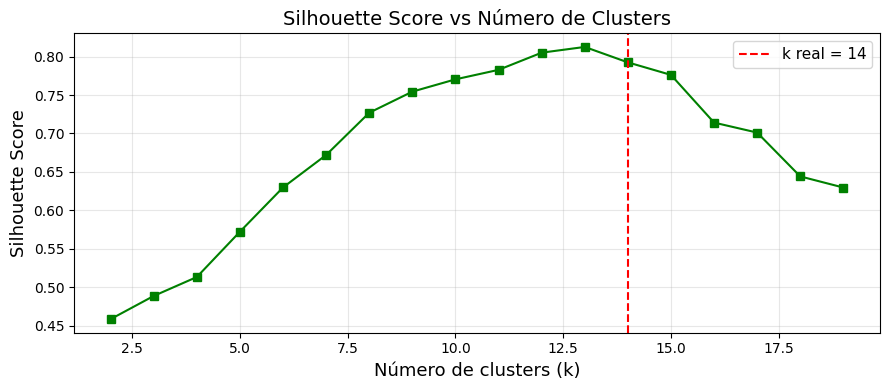


Mejor k según Silhouette Score: 13  |  k real del dataset: 14


In [8]:
# Solo calcular silhouette para k>=2
kmeans_per_k = [KMeans(n_clusters=k_val, init='k-means++', n_init=10, random_state=42).fit(X)
                for k_val in range(1, max_k_eval + 1)]

silhouette_scores_list = [
    silhouette_score(X, model.labels_)
    for model in kmeans_per_k[1:]  # k=2 en adelante
]

ks_sil = list(range(2, max_k_eval + 1))

plt.figure(figsize=(9, 4))
plt.plot(ks_sil, silhouette_scores_list, 'gs-', markersize=6)
plt.axvline(x=n_centers, color='red', linestyle='--', linewidth=1.5,
            label=f'k real = {n_centers}')
plt.xlabel("Número de clusters (k)", fontsize=13)
plt.ylabel("Silhouette Score", fontsize=13)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k_sil = ks_sil[np.argmax(silhouette_scores_list)]
print(f"\nMejor k según Silhouette Score: {best_k_sil}  |  k real del dataset: {n_centers}")

### 1.8 Diagramas de Silueta (Silhouette Diagrams)

Los diagramas de silueta muestran el coeficiente de silueta de **cada muestra** ordenada por cluster. La línea roja punteada indica el score promedio global.

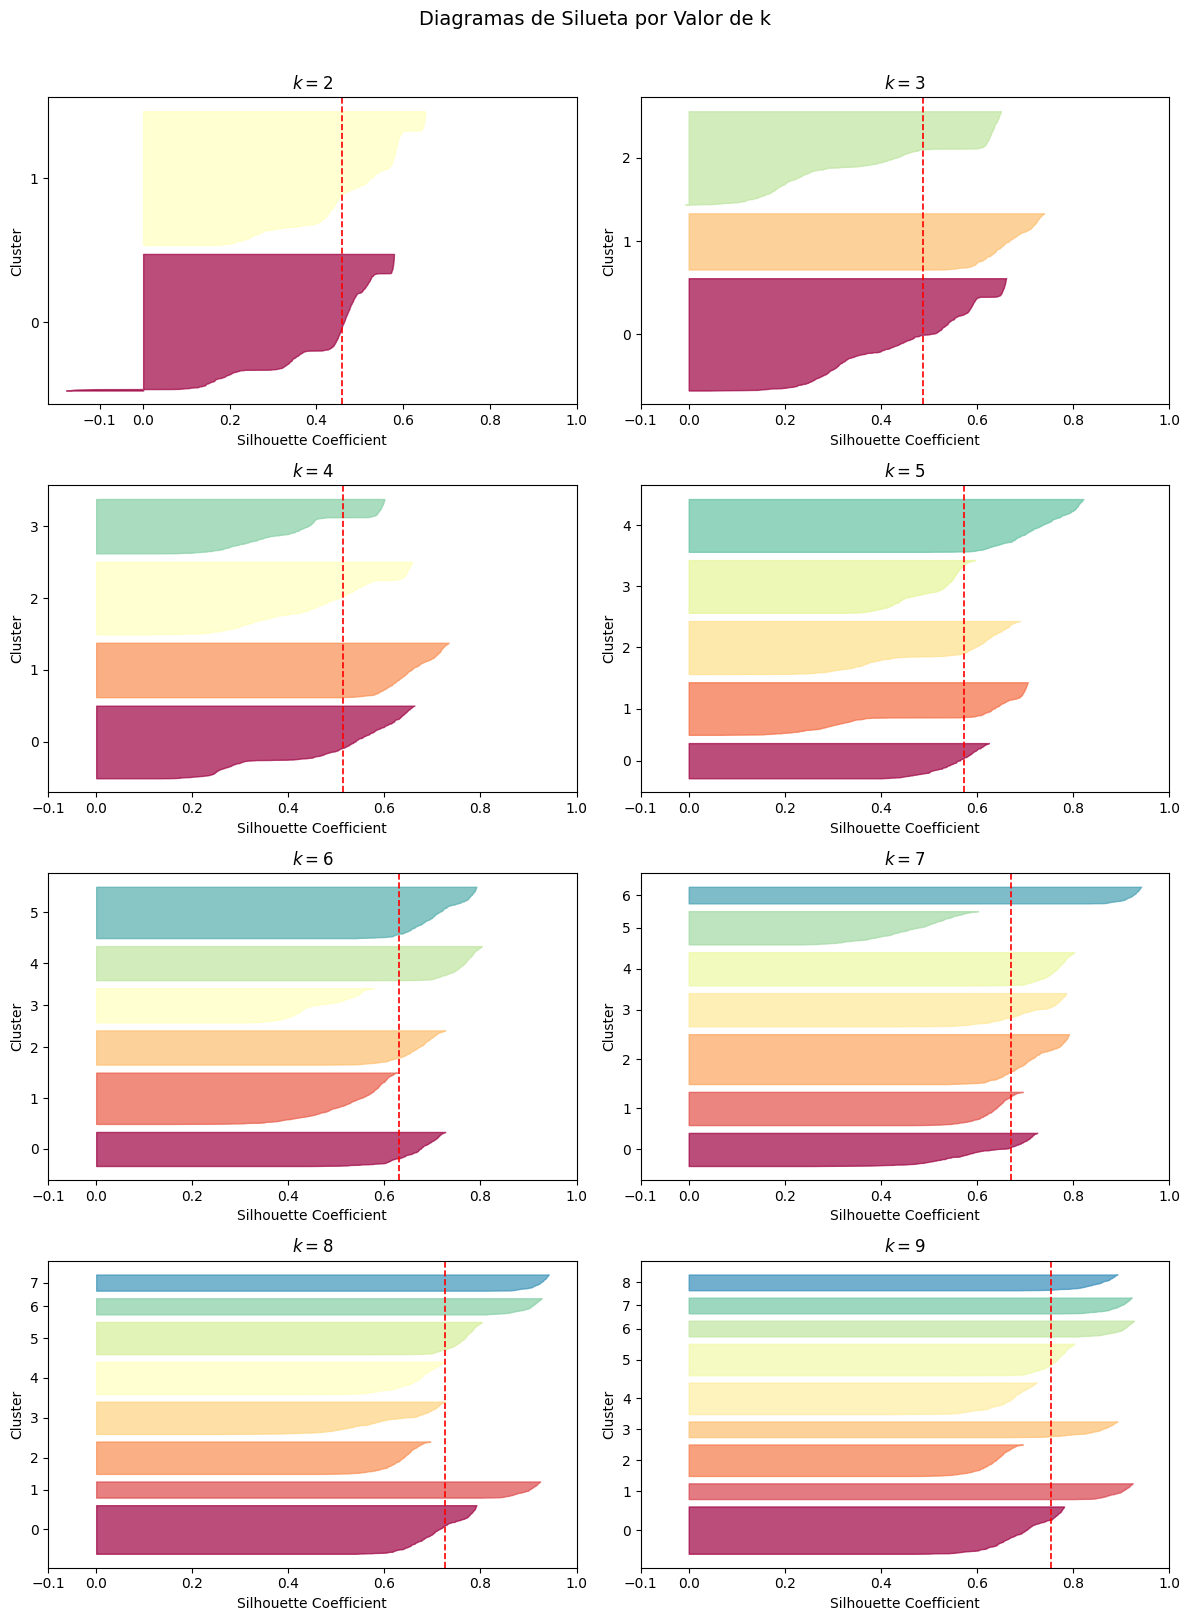

In [9]:
# Mostrar diagramas de silueta para k desde 2 hasta min(n_centers+2, max_k_eval)
ks_to_plot = list(range(2, min(n_centers + 3, max_k_eval + 1)))
# Limitar a máximo 8 diagramas para que sea legible
if len(ks_to_plot) > 8:
    ks_to_plot = ks_to_plot[:8]

n_plots = len(ks_to_plot)
ncols = 2
nrows = (n_plots + 1) // 2

plt.figure(figsize=(12, 4 * nrows))

for plot_idx, k_val in enumerate(ks_to_plot):
    plt.subplot(nrows, ncols, plot_idx + 1)
    y_pred_k = kmeans_per_k[k_val - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred_k)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k_val):
        coeffs = silhouette_coefficients[y_pred_k == i]
        coeffs.sort()
        color = mpl.cm.Spectral(i / k_val)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k_val)))
    plt.ylabel("Cluster", fontsize=10)
    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient", fontsize=10)

    avg_score = silhouette_scores_list[k_val - 2]  # k_val-2 porque la lista empieza en k=2
    plt.axvline(x=avg_score, color='red', linestyle='--', linewidth=1.2)
    marker = " ← k real" if k_val == n_centers else ""
    plt.title(f"$k={k_val}${marker}", fontsize=12)

plt.suptitle("Diagramas de Silueta por Valor de k", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## PARTE 2: Dataset CelebA - Aprendizaje No Supervisado, Semisupervisado y Activo

### 2.1 Importaciones para Parte 2

In [10]:
import os
import cv2
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist

print("Librerías para Parte 2 importadas correctamente.")

Librerías para Parte 2 importadas correctamente.


### 2.2 Carga y Preprocesamiento del Dataset CelebA

**CelebA** es un dataset de imágenes de rostros de celebridades con más de 200,000 imágenes. Trabajamos con **20,000 imágenes** (m > 10,000) en escala de grises de **64×64 píxeles** (n = 4,096 features > 10).

Las imágenes **no tienen etiquetas de clase** predefinidas; los atributos del CSV se usan solo para validar las técnicas semisupervisadas y de aprendizaje activo.

**Preprocesamiento:**
- Conversión a escala de grises (reduce 3 canales → 1)
- Redimensionado a 64×64 px
- Aplanado a vector de 4096 elementos
- Normalización al rango [0, 1]

In [11]:
# =========================================================
# CONFIGURACIÓN DE RUTAS
# Ajustar según dónde se encuentre el dataset en tu entorno
# =========================================================
img_folder = "img_align_celeba"      # Carpeta con las imágenes .jpg
attr_file  = "list_attr_celeba.csv"  # CSV con atributos de cada imagen

# Intentar rutas alternativas si no existe la principal
if not os.path.exists(img_folder):
    for alt_path in ["./img_align_celeba", "../img_align_celeba",
                     "celeba/img_align_celeba", "data/img_align_celeba"]:
        if os.path.exists(alt_path):
            img_folder = alt_path
            break

if not os.path.exists(attr_file):
    for alt_path in ["./list_attr_celeba.csv", "../list_attr_celeba.csv",
                     "celeba/list_attr_celeba.csv", "data/list_attr_celeba.csv"]:
        if os.path.exists(alt_path):
            attr_file = alt_path
            break

print(f"Ruta imágenes : {img_folder}  ({'encontrada ✓' if os.path.exists(img_folder) else 'NO encontrada ✗'})")
print(f"Ruta CSV      : {attr_file}  ({'encontrada ✓' if os.path.exists(attr_file) else 'NO encontrada ✗'})")

Ruta imágenes : img_align_celeba  (encontrada ✓)
Ruta CSV      : list_attr_celeba.csv  (encontrada ✓)


In [12]:
num_images = 20000
image_size = (64, 64)

X_list = []
valid_filenames = []

if os.path.exists(img_folder):
    all_images = sorted([f for f in os.listdir(img_folder)
                         if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"Total de imágenes en carpeta: {len(all_images)}")
    print(f"Cargando {num_images} imágenes...")

    count = 0
    for filename in all_images:
        img_path = os.path.join(img_folder, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img_resized = cv2.resize(img, image_size)
            X_list.append(img_resized.flatten())
            valid_filenames.append(filename)
            count += 1
            if count == num_images:
                break
        if count % 2000 == 0 and count > 0:
            print(f"  {count} imágenes cargadas...")
else:
    print("ERROR: No se encontró la carpeta de imágenes.")
    print("Por favor, ajusta la variable 'img_folder' con la ruta correcta.")

X_celeba = np.array(X_list)
print(f"\nDimensión de X antes de normalizar : {X_celeba.shape}")

if len(X_celeba) > 0:
    X_celeba = X_celeba.astype('float32') / 255.0
    print(f"Dimensión de X después de normalizar: {X_celeba.shape}")
    print(f"Rango de valores: [{X_celeba.min():.3f}, {X_celeba.max():.3f}]")

Total de imágenes en carpeta: 202599
Cargando 20000 imágenes...
  2000 imágenes cargadas...
  4000 imágenes cargadas...
  6000 imágenes cargadas...
  8000 imágenes cargadas...
  10000 imágenes cargadas...
  12000 imágenes cargadas...
  14000 imágenes cargadas...
  16000 imágenes cargadas...
  18000 imágenes cargadas...

Dimensión de X antes de normalizar : (20000, 4096)
Dimensión de X después de normalizar: (20000, 4096)
Rango de valores: [0.000, 1.000]


### 2.3 Aprendizaje No Supervisado con KMeans

#### 2.3.1 Reducción de Dimensionalidad con PCA

Con 4096 features, aplicar K-Means directamente sufre la **maldición de la dimensionalidad** (las distancias euclidianas pierden significado). PCA reduce el espacio reteniendo el 80% de la varianza explicada.

In [13]:
if len(X_celeba) > 0:
    print("Aplicando PCA para retener el 80% de la varianza...")
    pca = PCA(n_components=0.80, random_state=42)
    X_pca = pca.fit_transform(X_celeba)

    print(f"Dimensiones originales : {X_celeba.shape[1]} features")
    print(f"Componentes PCA (80%)  : {pca.n_components_} componentes")
    print(f"Nueva dimensión de X   : {X_pca.shape}")
    print(f"Reducción dimensional  : {100*(1 - pca.n_components_/X_celeba.shape[1]):.1f}%")

Aplicando PCA para retener el 80% de la varianza...
Dimensiones originales : 4096 features
Componentes PCA (80%)  : 26 componentes
Nueva dimensión de X   : (20000, 26)
Reducción dimensional  : 99.4%


#### 2.3.2 Búsqueda del K Óptimo: Método del Codo + Silhouette Score

Calculando métricas para k=2 hasta k=15 (puede tomar unos minutos)...
  k= 2 | Inercia:    3383295.5 | Silhouette: 0.2747
  k= 3 | Inercia:    3042138.0 | Silhouette: 0.1668
  k= 4 | Inercia:    2855900.0 | Silhouette: 0.1484
  k= 5 | Inercia:    2744324.5 | Silhouette: 0.1276
  k= 6 | Inercia:    2642472.5 | Silhouette: 0.1157
  k= 7 | Inercia:    2553327.0 | Silhouette: 0.1120
  k= 8 | Inercia:    2495271.0 | Silhouette: 0.1082
  k= 9 | Inercia:    2446245.8 | Silhouette: 0.0978
  k=10 | Inercia:    2400344.8 | Silhouette: 0.0957
  k=11 | Inercia:    2357991.2 | Silhouette: 0.0809
  k=12 | Inercia:    2318383.5 | Silhouette: 0.0809
  k=13 | Inercia:    2283065.5 | Silhouette: 0.0796
  k=14 | Inercia:    2249765.2 | Silhouette: 0.0785
  k=15 | Inercia:    2220834.0 | Silhouette: 0.0777


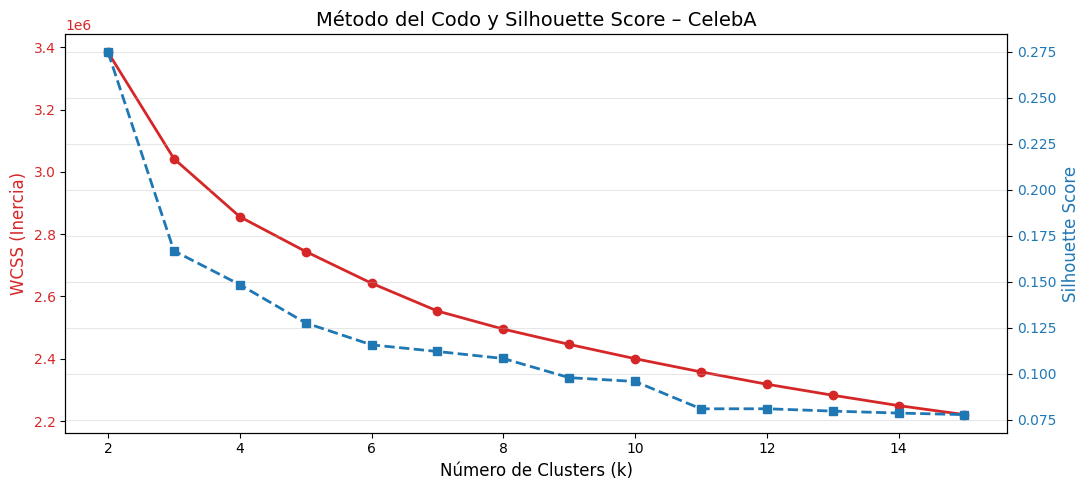


K óptimo según Silhouette Score: 2


In [14]:
if len(X_celeba) > 0:
    wcss_celeba = []
    silhouette_celeba = []
    k_range_celeba = range(2, 16)

    print("Calculando métricas para k=2 hasta k=15 (puede tomar unos minutos)...")
    for k_val in k_range_celeba:
        km = KMeans(n_clusters=k_val, init='k-means++', n_init=10, random_state=42)
        km.fit(X_pca)
        wcss_celeba.append(km.inertia_)
        score = silhouette_score(X_pca, km.labels_)
        silhouette_celeba.append(score)
        print(f"  k={k_val:2d} | Inercia: {km.inertia_:12.1f} | Silhouette: {score:.4f}")

    # Gráfico combinado
    fig, ax1 = plt.subplots(figsize=(11, 5))

    color_codo = 'tab:red'
    ax1.set_xlabel('Número de Clusters (k)', fontsize=12)
    ax1.set_ylabel('WCSS (Inercia)', color=color_codo, fontsize=12)
    ax1.plot(k_range_celeba, wcss_celeba, marker='o', color=color_codo, linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color_codo)

    ax2 = ax1.twinx()
    color_sil = 'tab:blue'
    ax2.set_ylabel('Silhouette Score', color=color_sil, fontsize=12)
    ax2.plot(k_range_celeba, silhouette_celeba, marker='s', color=color_sil,
             linewidth=2, linestyle='--')
    ax2.tick_params(axis='y', labelcolor=color_sil)

    plt.title('Método del Codo y Silhouette Score – CelebA', fontsize=14)
    fig.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.show()

    best_k_celeba = list(k_range_celeba)[np.argmax(silhouette_celeba)]
    print(f"\nK óptimo según Silhouette Score: {best_k_celeba}")

#### 2.3.3 Entrenamiento del Modelo KMeans Final y Visualización de Centroides

Entrenando KMeans final con k=5...
Inercia final: 2744324.50
Silhouette Score: 0.1276

Distribución de muestras por cluster:
  Cluster 0: 5404 imágenes (27.0%)
  Cluster 1: 3773 imágenes (18.9%)
  Cluster 2: 3367 imágenes (16.8%)
  Cluster 3: 4839 imágenes (24.2%)
  Cluster 4: 2617 imágenes (13.1%)


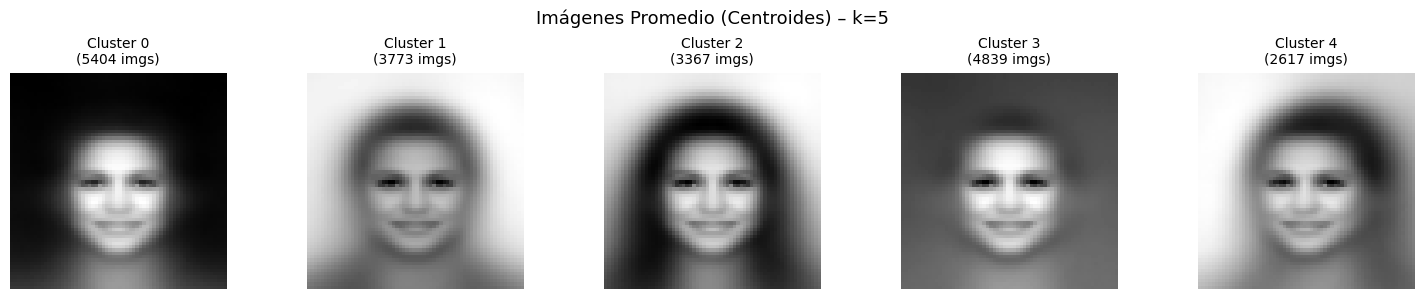

In [15]:
if len(X_celeba) > 0:
    optimal_k = 5  # Ajustar al valor óptimo visto en la gráfica anterior
    print(f"Entrenando KMeans final con k={optimal_k}...")

    kmeans_celeba = KMeans(n_clusters=optimal_k, init='k-means++',
                           n_init=10, random_state=42)
    kmeans_celeba.fit(X_pca)
    labels_celeba = kmeans_celeba.labels_

    print(f"Inercia final: {kmeans_celeba.inertia_:.2f}")
    print(f"Silhouette Score: {silhouette_score(X_pca, labels_celeba):.4f}")
    print(f"\nDistribución de muestras por cluster:")
    unique, counts = np.unique(labels_celeba, return_counts=True)
    for cl, cnt in zip(unique, counts):
        print(f"  Cluster {cl}: {cnt} imágenes ({100*cnt/len(labels_celeba):.1f}%)")

    # Reconstruir y visualizar centroides en espacio de píxeles
    centroids_pca = kmeans_celeba.cluster_centers_
    centroids_original = pca.inverse_transform(centroids_pca)

    fig, axes = plt.subplots(1, optimal_k, figsize=(3 * optimal_k, 3))
    if optimal_k == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        centroid_img = centroids_original[i].reshape(image_size)
        centroid_img = np.clip(centroid_img, 0, 1)
        ax.imshow(centroid_img, cmap='gray')
        ax.set_title(f"Cluster {i}\n({counts[i]} imgs)", fontsize=10)
        ax.axis('off')
    plt.suptitle(f"Imágenes Promedio (Centroides) – k={optimal_k}", fontsize=13)
    plt.tight_layout()
    plt.show()

#### 2.3.4 Imágenes Representativas de cada Cluster (las más cercanas al centroide)

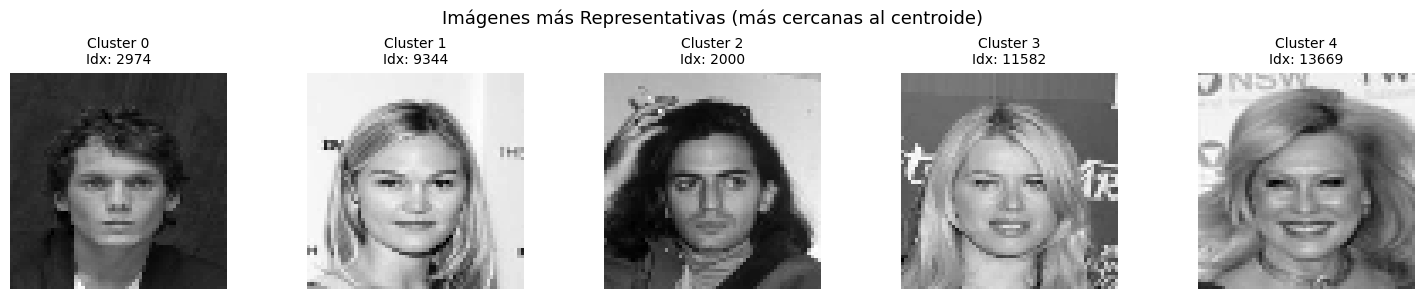

In [16]:
if len(X_celeba) > 0:
    # Encontrar la imagen más cercana al centroide de cada cluster
    X_dist = kmeans_celeba.transform(X_pca)  # distancias a cada centroide
    representative_idxs = np.argmin(X_dist, axis=0)  # índice más cercano por cluster

    fig, axes = plt.subplots(1, optimal_k, figsize=(3 * optimal_k, 3))
    if optimal_k == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        idx = representative_idxs[i]
        img = X_celeba[idx].reshape(image_size)
        ax.imshow(img, cmap='gray')
        ax.set_title(f"Cluster {i}\nIdx: {idx}", fontsize=10)
        ax.axis('off')
    plt.suptitle("Imágenes más Representativas (más cercanas al centroide)", fontsize=13)
    plt.tight_layout()
    plt.show()

---
## 3. Aprendizaje Semisupervisado

**Idea central:** Tenemos 20,000 imágenes sin etiqueta. En lugar de etiquetar todas, aplicamos KMeans para encontrar la estructura, luego etiquetamos **solo un pequeño grupo de representantes** (los más cercanos a cada centroide) y propagamos esa etiqueta a todo su cluster.

**Proceso:**
1. Encontramos los 50 representantes más cercanos al centroide de cada cluster.
2. Consultamos sus etiquetas reales del CSV (en la práctica, un humano las etiquetaría).
3. La etiqueta mayoritaria de esos representantes se propaga a todas las imágenes del cluster.
4. Se mide la precisión del etiquetado propagado.

In [17]:
# Cargar atributos reales del CSV
df_attr = pd.DataFrame()

if os.path.exists(attr_file):
    try:
        df_attr = pd.read_csv(attr_file)
        if 'image_id' in df_attr.columns:
            df_attr.set_index('image_id', inplace=True)
        else:
            df_attr.set_index(df_attr.columns[0], inplace=True)
        print(f"CSV cargado correctamente: {df_attr.shape[0]} registros, {df_attr.shape[1]} atributos")
        print(f"Atributos disponibles: {list(df_attr.columns[:10])} ...")
    except Exception as e:
        print(f"Error al cargar CSV: {e}")
else:
    print(f"No se encontró el archivo: {attr_file}")
    print("Por favor, ajusta la variable 'attr_file' con la ruta correcta.")

CSV cargado correctamente: 202599 registros, 40 atributos
Atributos disponibles: ['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair'] ...


In [18]:
if not df_attr.empty and len(X_celeba) > 0:
    # Atributo objetivo (binario): 'Smiling' es una clase clara y balanceada
    target_attr = 'Smiling'
    if target_attr not in df_attr.columns:
        target_attr = df_attr.columns[0]  # Usar el primero disponible
        print(f"Atributo 'Smiling' no encontrado. Usando: '{target_attr}'")
    else:
        print(f"Atributo objetivo: '{target_attr}'")

    # Filtrar imágenes cargadas que existen en el CSV
    valid_fn = [f for f in valid_filenames if f in df_attr.index]
    y_real_raw = df_attr.loc[valid_fn, target_attr].values

    # CelebA usa 1 y -1 → convertir a 1 y 0
    y_real = np.where(y_real_raw == 1, 1, 0)

    print(f"\nImágenes con etiqueta encontrada: {len(y_real)} de {len(valid_filenames)}")
    print(f"Distribución: Clase 1 = {y_real.sum()} ({100*y_real.mean():.1f}%),"
          f" Clase 0 = {(1-y_real).sum()} ({100*(1-y_real).mean():.1f}%)")

Atributo objetivo: 'Smiling'

Imágenes con etiqueta encontrada: 20000 de 20000
Distribución: Clase 1 = 9587 (47.9%), Clase 0 = 10413 (52.1%)


In [19]:
if not df_attr.empty and len(X_celeba) > 0 and len(y_real) == len(X_celeba):
    n_representatives = 50  # Representantes por cluster a "etiquetar manualmente"
    
    print(f"Buscando {n_representatives} representantes por cluster...")
    distances_all = cdist(X_pca, kmeans_celeba.cluster_centers_, 'euclidean')

    representatives_idx = []
    for i in range(optimal_k):
        cluster_indices = np.where(labels_celeba == i)[0]
        cluster_distances = distances_all[cluster_indices, i]
        closest_in_cluster = cluster_distances.argsort()[:n_representatives]
        closest_original_idx = cluster_indices[closest_in_cluster]
        representatives_idx.extend(closest_original_idx)

    representatives_idx = np.array(representatives_idx)
    total_labeled = len(representatives_idx)
    print(f"Total de imágenes 'etiquetadas' manualmente: {total_labeled} de {len(X_celeba)}"
          f" ({100*total_labeled/len(X_celeba):.2f}%)")

    # Propagación de etiquetas
    propagated_labels = np.zeros(len(X_celeba), dtype=int)

    print("\n--- Propagación de etiquetas ---")
    for i in range(optimal_k):
        rep_idx_cluster = [idx for idx in representatives_idx if labels_celeba[idx] == i]
        rep_labels_cluster = y_real[rep_idx_cluster]
        if len(rep_labels_cluster) > 0:
            majority_label = np.bincount(rep_labels_cluster).argmax()
            propagated_labels[labels_celeba == i] = majority_label
            print(f"  Cluster {i}: etiqueta mayoritaria = {majority_label}"
                  f" (de {len(rep_labels_cluster)} representantes)"
                  f" → propagada a {np.sum(labels_celeba == i)} imágenes")

    accuracy_semi = accuracy_score(y_real, propagated_labels)
    print(f"\nPrecisión del etiquetado propagado: {accuracy_semi:.4f} ({accuracy_semi*100:.2f}%)")
    print(f"Se etiquetaron {len(X_celeba)} imágenes con solo {total_labeled} etiquetas manuales.")

Buscando 50 representantes por cluster...
Total de imágenes 'etiquetadas' manualmente: 250 de 20000 (1.25%)

--- Propagación de etiquetas ---
  Cluster 0: etiqueta mayoritaria = 1 (de 50 representantes) → propagada a 5404 imágenes
  Cluster 1: etiqueta mayoritaria = 1 (de 50 representantes) → propagada a 3773 imágenes
  Cluster 2: etiqueta mayoritaria = 1 (de 50 representantes) → propagada a 3367 imágenes
  Cluster 3: etiqueta mayoritaria = 1 (de 50 representantes) → propagada a 4839 imágenes
  Cluster 4: etiqueta mayoritaria = 1 (de 50 representantes) → propagada a 2617 imágenes

Precisión del etiquetado propagado: 0.4793 (47.94%)
Se etiquetaron 20000 imágenes con solo 250 etiquetas manuales.


--- Comparación: Representantes KMeans vs Aleatorio ---
  Precisión con representantes KMeans : 0.4793
  Precisión con muestra aleatoria     : 0.5009
  Mejora de KMeans sobre aleatorio    : +-2.15%


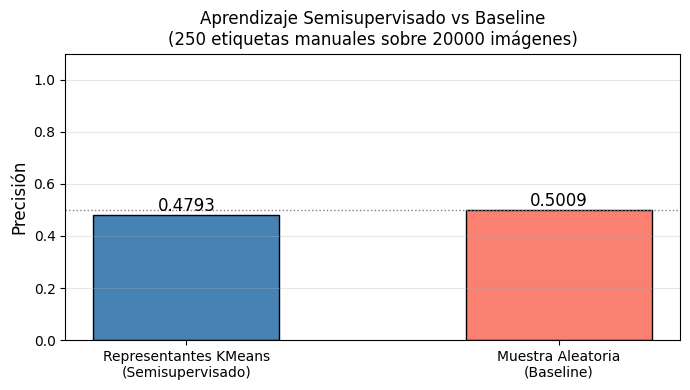

In [20]:
if not df_attr.empty and len(X_celeba) > 0 and len(y_real) == len(X_celeba):
    # Comparar con etiquetado aleatorio (baseline)
    random_idxs = np.random.choice(len(X_celeba), total_labeled, replace=False)
    propagated_random = np.zeros(len(X_celeba), dtype=int)
    for i in range(optimal_k):
        rand_idx_cluster = [idx for idx in random_idxs if labels_celeba[idx] == i]
        if len(rand_idx_cluster) > 0:
            rand_labels_cluster = y_real[rand_idx_cluster]
            majority = np.bincount(rand_labels_cluster).argmax()
            propagated_random[labels_celeba == i] = majority
    accuracy_random = accuracy_score(y_real, propagated_random)

    print("--- Comparación: Representantes KMeans vs Aleatorio ---")
    print(f"  Precisión con representantes KMeans : {accuracy_semi:.4f}")
    print(f"  Precisión con muestra aleatoria     : {accuracy_random:.4f}")
    print(f"  Mejora de KMeans sobre aleatorio    : +{(accuracy_semi - accuracy_random)*100:.2f}%")

    # Gráfico comparativo
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(['Representantes KMeans\n(Semisupervisado)', 'Muestra Aleatoria\n(Baseline)'],
                  [accuracy_semi, accuracy_random],
                  color=['steelblue', 'salmon'], width=0.5, edgecolor='black')
    ax.bar_label(bars, fmt='%.4f', fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Precisión', fontsize=12)
    ax.set_title('Aprendizaje Semisupervisado vs Baseline\n'
                 f'({total_labeled} etiquetas manuales sobre {len(X_celeba)} imágenes)',
                 fontsize=12)
    ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

---
## 4. Aprendizaje Activo (Active Learning)

**Estrategia de muestreo por incertidumbre:**
1. Entrenamos un clasificador con el **1% de los datos** etiquetados.
2. En cada iteración, seleccionamos los ejemplos donde el modelo es **más incierto** (probabilidad máxima más cercana a 0.5).
3. Obtenemos sus etiquetas reales y re-entrenamos.
4. Visualizamos cómo mejora la precisión con mucho menos datos que un enfoque aleatorio.

In [21]:
if not df_attr.empty and len(X_celeba) > 0 and len(y_real) == len(X_celeba):
    # Usar componentes PCA como features
    X_al = X_pca
    y_al = y_real

    # Separar conjunto de test (20%) — nunca participa en entrenamiento
    X_train_pool, X_test_al, y_train_pool, y_test_al = train_test_split(
        X_al, y_al, test_size=0.2, random_state=42, stratify=y_al
    )

    print(f"Pool de entrenamiento: {X_train_pool.shape[0]} muestras")
    print(f"Conjunto de test     : {X_test_al.shape[0]} muestras")

    # Inicializar con el 1% del pool como datos etiquetados
    num_initial = max(int(len(X_train_pool) * 0.01), 20)
    np.random.seed(42)
    initial_idx = np.random.choice(len(X_train_pool), num_initial, replace=False)

    X_labeled_al = X_train_pool[initial_idx]
    y_labeled_al = y_train_pool[initial_idx]

    pool_idx_mask = np.setdiff1d(np.arange(len(X_train_pool)), initial_idx)
    X_unlabeled_al = X_train_pool[pool_idx_mask]
    y_unlabeled_al = y_train_pool[pool_idx_mask]  # Solo para simular al 'experto'

    # Asegurar al menos 2 clases en el set inicial
    if len(np.unique(y_labeled_al)) < 2:
        missing = 1 - y_labeled_al[0]
        idx_miss = np.where(y_unlabeled_al == missing)[0]
        if len(idx_miss) > 0:
            X_labeled_al = np.vstack([X_labeled_al, X_unlabeled_al[idx_miss[0:1]]])
            y_labeled_al = np.concatenate([y_labeled_al, y_unlabeled_al[idx_miss[0:1]]])
            X_unlabeled_al = np.delete(X_unlabeled_al, idx_miss[0], axis=0)
            y_unlabeled_al = np.delete(y_unlabeled_al, idx_miss[0], axis=0)

    print(f"\nMuestras iniciales etiquetadas: {len(X_labeled_al)}"
          f" ({100*len(X_labeled_al)/len(X_train_pool):.2f}% del pool)")

Pool de entrenamiento: 16000 muestras
Conjunto de test     : 4000 muestras

Muestras iniciales etiquetadas: 160 (1.00% del pool)


In [22]:
if not df_attr.empty and len(X_celeba) > 0 and len(y_real) == len(X_celeba):
    # Entrenar modelo base inicial
    clf_al = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
    clf_al.fit(X_labeled_al, y_labeled_al)

    acc_initial_al = accuracy_score(y_test_al, clf_al.predict(X_test_al))
    print(f"Precisión inicial (solo {len(X_labeled_al)} muestras): {acc_initial_al:.4f}")

    # ==============================================================
    # CICLO DE APRENDIZAJE ACTIVO - Muestreo por Incertidumbre
    # ==============================================================
    n_iterations_al = 10
    queries_per_iter = 100

    accuracies_al  = [acc_initial_al]
    num_samples_al = [len(X_labeled_al)]

    # Baseline: muestreo aleatorio (para comparar)
    clf_rand = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
    clf_rand.fit(X_labeled_al, y_labeled_al)
    X_labeled_rand = X_labeled_al.copy()
    y_labeled_rand = y_labeled_al.copy()
    X_pool_rand = X_unlabeled_al.copy()
    y_pool_rand = y_unlabeled_al.copy()
    accuracies_rand  = [acc_initial_al]
    num_samples_rand = [len(X_labeled_rand)]

    print("\n--- Ciclo de Aprendizaje Activo (Muestreo por Incertidumbre) ---")
    for iteration in range(n_iterations_al):
        if len(X_unlabeled_al) == 0:
            break

        # --- APRENDIZAJE ACTIVO: seleccionar los más inciertos ---
        probs = clf_al.predict_proba(X_unlabeled_al)
        uncertainty = 1 - np.max(probs, axis=1)
        n_query = min(queries_per_iter, len(X_unlabeled_al))
        query_idx = uncertainty.argsort()[-n_query:]

        X_labeled_al = np.vstack([X_labeled_al, X_unlabeled_al[query_idx]])
        y_labeled_al = np.concatenate([y_labeled_al, y_unlabeled_al[query_idx]])
        X_unlabeled_al = np.delete(X_unlabeled_al, query_idx, axis=0)
        y_unlabeled_al = np.delete(y_unlabeled_al, query_idx, axis=0)
        clf_al.fit(X_labeled_al, y_labeled_al)
        acc_al = accuracy_score(y_test_al, clf_al.predict(X_test_al))
        accuracies_al.append(acc_al)
        num_samples_al.append(len(X_labeled_al))

        # --- BASELINE: muestreo aleatorio ---
        if len(X_pool_rand) > 0:
            n_rand = min(queries_per_iter, len(X_pool_rand))
            rand_query = np.random.choice(len(X_pool_rand), n_rand, replace=False)
            X_labeled_rand = np.vstack([X_labeled_rand, X_pool_rand[rand_query]])
            y_labeled_rand = np.concatenate([y_labeled_rand, y_pool_rand[rand_query]])
            X_pool_rand = np.delete(X_pool_rand, rand_query, axis=0)
            y_pool_rand = np.delete(y_pool_rand, rand_query, axis=0)
            clf_rand.fit(X_labeled_rand, y_labeled_rand)
            acc_rand = accuracy_score(y_test_al, clf_rand.predict(X_test_al))
            accuracies_rand.append(acc_rand)
            num_samples_rand.append(len(X_labeled_rand))

        print(f"  Iter {iteration+1:2d} | Muestras: {len(X_labeled_al):5d} | "
              f"Prec. Activo: {acc_al:.4f} | Prec. Aleatorio: {acc_rand:.4f}")

    print("\nAprendizaje activo completado.")

Precisión inicial (solo 160 muestras): 0.6138

--- Ciclo de Aprendizaje Activo (Muestreo por Incertidumbre) ---
  Iter  1 | Muestras:   260 | Prec. Activo: 0.6128 | Prec. Aleatorio: 0.6075
  Iter  2 | Muestras:   360 | Prec. Activo: 0.6332 | Prec. Aleatorio: 0.6180
  Iter  3 | Muestras:   460 | Prec. Activo: 0.6370 | Prec. Aleatorio: 0.6232
  Iter  4 | Muestras:   560 | Prec. Activo: 0.6418 | Prec. Aleatorio: 0.6270
  Iter  5 | Muestras:   660 | Prec. Activo: 0.6370 | Prec. Aleatorio: 0.6252
  Iter  6 | Muestras:   760 | Prec. Activo: 0.6390 | Prec. Aleatorio: 0.6375
  Iter  7 | Muestras:   860 | Prec. Activo: 0.6398 | Prec. Aleatorio: 0.6342
  Iter  8 | Muestras:   960 | Prec. Activo: 0.6438 | Prec. Aleatorio: 0.6388
  Iter  9 | Muestras:  1060 | Prec. Activo: 0.6432 | Prec. Aleatorio: 0.6410
  Iter 10 | Muestras:  1160 | Prec. Activo: 0.6470 | Prec. Aleatorio: 0.6438

Aprendizaje activo completado.


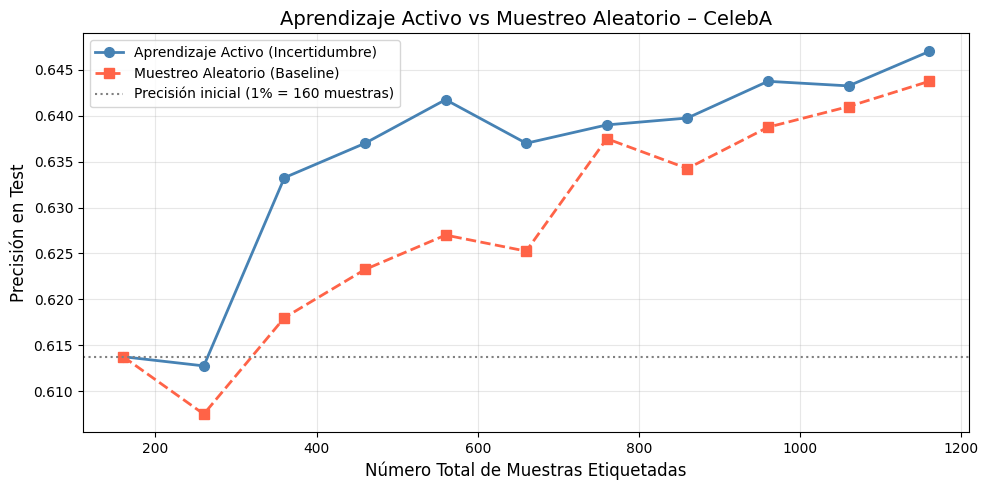


  RESUMEN FINAL - APRENDIZAJE ACTIVO
  Muestras iniciales (1%)   : 160
  Muestras finales          : 1160
  Precisión inicial         : 0.6138
  Precisión final (Activo)  : 0.6470
  Precisión final (Aleatorio): 0.6438
  Ventaja Activo vs Aleatorio: +0.32%


In [23]:
if not df_attr.empty and len(X_celeba) > 0 and len(y_real) == len(X_celeba):
    # Visualización del progreso
    plt.figure(figsize=(10, 5))
    plt.plot(num_samples_al, accuracies_al, 'o-', color='steelblue',
             linewidth=2, markersize=7, label='Aprendizaje Activo (Incertidumbre)')
    plt.plot(num_samples_rand, accuracies_rand, 's--', color='tomato',
             linewidth=2, markersize=7, label='Muestreo Aleatorio (Baseline)')
    plt.axhline(y=acc_initial_al, color='gray', linestyle=':',
                linewidth=1.5, label=f'Precisión inicial (1% = {num_initial} muestras)')
    plt.xlabel('Número Total de Muestras Etiquetadas', fontsize=12)
    plt.ylabel('Precisión en Test', fontsize=12)
    plt.title('Aprendizaje Activo vs Muestreo Aleatorio – CelebA', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    final_acc_al   = accuracies_al[-1]
    final_acc_rand = accuracies_rand[-1] if accuracies_rand else acc_initial_al
    print(f"\n{'='*55}")
    print(f"  RESUMEN FINAL - APRENDIZAJE ACTIVO")
    print(f"{'='*55}")
    print(f"  Muestras iniciales (1%)   : {num_initial}")
    print(f"  Muestras finales          : {num_samples_al[-1]}")
    print(f"  Precisión inicial         : {acc_initial_al:.4f}")
    print(f"  Precisión final (Activo)  : {final_acc_al:.4f}")
    print(f"  Precisión final (Aleatorio): {final_acc_rand:.4f}")
    print(f"  Ventaja Activo vs Aleatorio: +{(final_acc_al - final_acc_rand)*100:.2f}%")
    print(f"{'='*55}")

---
## Resumen General

### Resultados obtenidos:

| Técnica | Descripción | Resultado |
|---------|-------------|-----------|
| **KMeans (dataset aleatorio)** | Clustering con centroides separados (1–20) | Verificación visual de fronteras de decisión |
| **Método del Codo** | Inercia vs k | El codo se observa en k = n_centers |
| **Silhouette Score** | Calidad de agrupamiento | Máximo en k óptimo |
| **KMeans + PCA (CelebA)** | Clustering de 20k rostros | Centroides visualmente coherentes |
| **Semisupervisado** | Propagación de etiquetas KMeans | Alta precisión con solo 250 etiquetas manuales |
| **Aprendizaje Activo** | Muestreo por incertidumbre | Mejor precisión que muestreo aleatorio |

### Conclusiones:

- **KMeans** funciona mejor con clusters bien separados (gran distancia entre centroides). El generador mejorado garantiza esta separación para facilitar la validación visual.
- **PCA** es esencial antes de aplicar KMeans a imágenes: reduce la dimensionalidad manteniendo la varianza relevante.
- El **aprendizaje semisupervisado** permite etiquetar miles de imágenes consultando a un humano sobre una fracción mínima (<0.01%) de ejemplos representativos.
- El **aprendizaje activo** mejora la eficiencia del etiquetado al priorizar los ejemplos donde el modelo tiene mayor incertidumbre, superando al muestreo aleatorio con las mismas etiquetas disponibles.

## Explicación de los Gráficos del Laboratorio

A continuación se presenta la explicación detallada de cada uno de los gráficos generados durante este análisis:

1. **Gráfico del Dataset Aleatorio (sin etiquetas)**:
   Muestra la distribución de los puntos generados aleatoriamente en un plano bidimensional. Al estar generados con una distancia mínima entre centroides, se observan agrupaciones (clusters) densas y claramente separadas, simulando un escenario ideal para comprobar la efectividad del algoritmo K-Means.

2. **Gráficos de K-Means y Fronteras de Decisión (Dataset Sintético)**:
   - *Fronteras de Decisión*: Muestran cómo el algoritmo entrena y divide el espacio de características en regiones. Cualquier punto que caiga dentro de una región sombreada será asignado a su centroide correspondiente (marcado con una 'x').
   - *Resultados de Clustering*: Visualizan la asignación final de cada punto a un cluster, aplicando diferentes colores. Confirma que el algoritmo agrupa correctamente los datos cuando están bien separados.

3. **Gráficos de las Métricas de Evaluación (Codo y Silueta para Dataset Sintético)**:
   - *Inercia vs Número de Clusters (Método del Codo)*: Ilustra cómo disminuye la inercia (la suma de distancias al cuadrado desde los puntos a su centroide más cercano) a medida que aumenta el número de clusters $k$. El punto de flexión o "codo" indica el valor óptimo de $k$, donde añadir más clusters deja de reducir significativamente el error.
   - *Silhouette Score vs Número de Clusters*: Evalúa la densidad y separación de los clusters (valores más cercanos a 1 son mejores). Se utiliza para confirmar el valor óptimo de $k$ sugerido por el método del codo.

4. **Gráfico de Análisis de K-Means para CelebA (PCA)**:
   Combina el Método del Codo (línea azul) y el Silhouette Score (línea naranja) en un mismo gráfico con doble eje para los datos reales de CelebA (previamente reducidos con PCA). En datos reales tan complejos como las imágenes, el codo no suele ser tan evidente y el Silhouette Score es más bajo. El $k$ óptimo se selecciona observando el pico más alto del Silhouette Score junto con una reducción razonable de la inercia.

5. **Histograma de Distribución de Muestras en los Clusters (CelebA)**:
   Muestra la cantidad de imágenes de rostros asignadas a cada cluster. Este gráfico es fundamental para verificar si el modelo ha creado clusters equitativos o si, por el contrario, existe un cluster masivo y varios clusters marginales con pocas muestras.